In [1]:
import pandas as pd
import unidecode


In [97]:
df_ipp = pd.read_excel('./outputs/df_res.xlsx')
df_nomes_parls_evang = pd.read_excel('./parlamentares_evangelicos.xlsx', sheet_name='nomes')
df_parls_detalhes = pd.read_csv(r'data\df_parl_detalhes.csv')

In [98]:
def treat_name(name):
    name = unidecode.unidecode(name).strip().lower()
    return name

In [99]:
df_nomes_parls_evang['nome_tratado'] = df_nomes_parls_evang['nome'].apply(treat_name)
df_ipp['nome_tratado'] = df_ipp['ultimoStatus.nome'].apply(treat_name)

In [100]:
df_merge = df_ipp.merge(df_nomes_parls_evang, on='nome_tratado', how='left')
df_merge['is_evangelico'] = df_merge['nome'].isna()

df_merge

,id,idLegislatura,ultimoStatus.nome,ultimoStatus.siglaPartido,sexo,dataNascimento,escolaridade,idade_posse,tempo_atuacao_dias,tempo_atuacao_percent,...,dim_comprometimento,dim_carreira,dim_fidelidade,dim_comprometimento_norm,dim_carreira_norm,dim_fidelidade_norm,ipp,nome_tratado,nome,is_evangelico
0,1500,48,MÁRIO LIMA,PMDB,M,1935-02-19,Secundário,51,1460,1.00,...,1.094996,0.385542,0.111111,0.109317,0.381093,0.055556,0.181989,mario lima,NaN,True
1,1501,48,MAURÍCIO FRUET,PMDB,M,1939-08-12,Superior,47,1460,1.00,...,0.943396,0.507544,0.111111,0.094183,0.501687,0.055556,0.217142,mauricio fruet,NaN,True
2,1502,48,OSWALDO ALMEIDA,PL*,M,1933-10-22,Superior,53,1460,1.00,...,0.943396,0.361446,0.111111,0.094183,0.357275,0.055556,0.169004,oswaldo almeida,NaN,True
3,1503,48,OSWALDO LIMA FILHO,PMDB,M,1921-04-26,Superior,65,1460,1.00,...,0.943396,0.274010,0.111111,0.094183,0.270848,0.055556,0.140195,oswaldo lima filho,NaN,True
4,1504,48,TITO COSTA,PMDB,M,1922-12-31,Superior,64,1460,1.00,...,1.183677,0.245582,0.111111,0.118171,0.242748,0.055556,0.138825,tito costa,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6245,229225,57,Missionária Michele Collins,PP,F,1977-10-17,0,45,85,0.15,...,0.141509,0.457831,0.111111,0.014127,0.452548,0.055556,0.174077,missionaria michele collins,NaN,True
6246,229259,57,Pedro Tourinho,PT,M,1981-12-19,0,41,80,0.14,...,0.132075,0.506024,0.111111,0.013186,0.500184,0.055556,0.189642,pedro tourinho,NaN,True
6247,229333,57,Gláucia Santiago,PL,F,1960-02-20,0,62,79,0.14,...,0.132075,0.253012,0.111111,0.013186,0.250092,0.055556,0.106278,glaucia santiago,NaN,True
6248,229432,57,Luiz Fernando Vampiro,MDB,M,1973-11-07,Superior,49,72,0.13,...,0.122642,0.409639,0.111111,0.012244,0.404911,0.055556,0.157570,luiz fernando vampiro,NaN,True


# parlamentares detalhes

In [101]:
columns_1 = ['id', 'ultimoStatus.siglaPartido', 'ultimoStatus.siglaUf', 'escolaridade', 'sexo']

In [102]:
df_psm = (
    df_parls_detalhes[columns_1]
    .merge(df_merge[['id', 'is_evangelico']].drop_duplicates(), on='id')
    .join(
        pd.get_dummies(
            df_parls_detalhes["ultimoStatus.siglaPartido"], prefix="siglaPartido_"
        )
    )
    .join(pd.get_dummies(df_parls_detalhes["ultimoStatus.siglaUf"], prefix="siglaUF_"))
    .join(pd.get_dummies(df_parls_detalhes["escolaridade"], prefix="escolaridade_"))
    .join(pd.get_dummies(df_parls_detalhes["sexo"], prefix="sexo_"))
    .iloc[:, 5:]
)

df_psm['id'] = df_parls_detalhes['id']

In [103]:
df_psm

,is_evangelico,siglaPartido__AVANTE,siglaPartido__CIDADANIA,siglaPartido__DEM,siglaPartido__MDB,siglaPartido__NOVO,siglaPartido__PATRI,siglaPartido__PATRIOTA,siglaPartido__PCB**,siglaPartido__PCdoB,...,escolaridade__Primário,escolaridade__Primário Incompleto,escolaridade__Pós-Graduação,escolaridade__Secundário,escolaridade__Secundário Incompleto,escolaridade__Superior,escolaridade__Superior Incompleto,sexo__F,sexo__M,id
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,73729
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139265
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139269
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139268
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3117,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139250
3118,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139248
3119,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,139252
3120,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,139251


# PSM

In [104]:
from psmpy import PsmPy
from psmpy.functions import cohenD

In [105]:
psm = PsmPy(df_psm, treatment='is_evangelico', indx='id', exclude = [])
psm.logistic_ps(balance = True)

In [106]:
psm.predicted_data

,id,siglaPartido__AVANTE,siglaPartido__CIDADANIA,siglaPartido__DEM,siglaPartido__MDB,siglaPartido__NOVO,siglaPartido__PATRI,siglaPartido__PATRIOTA,siglaPartido__PCB**,siglaPartido__PCdoB,...,escolaridade__Pós-Graduação,escolaridade__Secundário,escolaridade__Secundário Incompleto,escolaridade__Superior,escolaridade__Superior Incompleto,sexo__F,sexo__M,propensity_score,propensity_logit,is_evangelico
0,139285,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,True,False,0.302605,-0.834924,0
1,73768,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.267164,-1.009057,0
2,73778,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.254912,-1.072585,0
3,73808,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.314314,-0.780029,0
4,73891,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,True,0.190775,-1.444980,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3117,139250,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.733996,1.014994,1
3118,139248,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.658262,0.655560,1
3119,139252,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,True,0.763769,1.173455,1
3120,139251,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,0.733261,1.011229,1


In [107]:
psm.knn_matched(matcher='propensity_logit', replacement=False, caliper=None, drop_unmatched=True)

C:\Users\caca_\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\psmpy\psmpy.py:363: UserWarning: Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False
  warnings.warn('Some values do not have a match. These are dropped for purposes of establishing a matched dataframe, and subsequent calculations and plots (effect size). If you do not wish this to be the case please set drop_unmatched=False')


In [108]:
psm.matched_ids

,id,matched_ID
0,139285,220628
1,73768,174314
2,73778,141463
3,73808,204509
4,73891,73788
...,...,...
536,73578,160654
537,73583,74272
538,73590,160557
539,73691,139164


# Comparação das amostras

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
df = df_merge[df_merge['id'].isin(psm.df_matched['id'])][['ipp', 'idLegislatura', 'is_evangelico']]
df = df[df['idLegislatura']> 50]

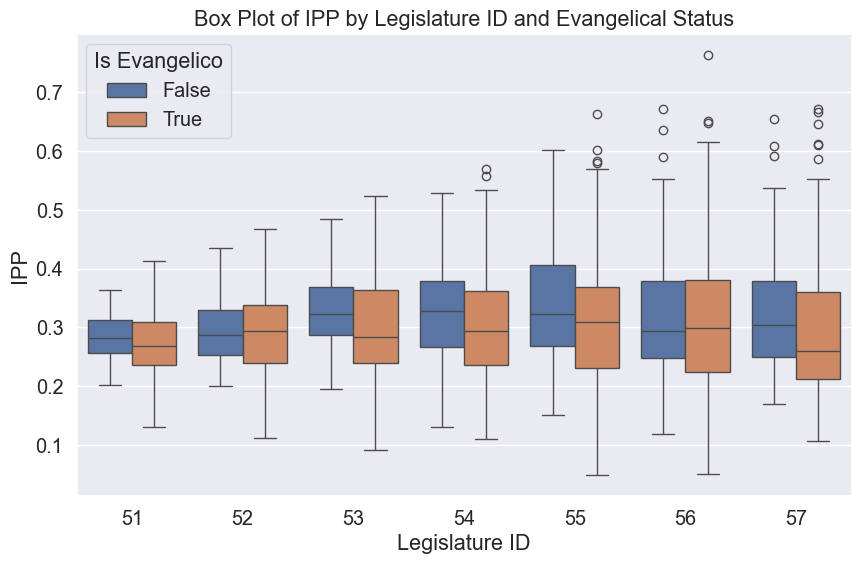

In [121]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='idLegislatura', y='ipp', hue='is_evangelico', data=df)
plt.xlabel('Legislature ID')
plt.ylabel('IPP')
plt.title('Box Plot of IPP by Legislature ID and Evangelical Status')
plt.legend(title='Is Evangelico')
plt.show()

In [124]:
df_merge.to_excel('df_evangelicos_ipp.xlsx')